In [1]:
import xarray as xr

ds = xr.open_dataset("/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc")
ds

<xarray.Dataset>
Dimensions:                  (lat: 89, lon: 1280, year: 85)
Coordinates:
  * year                     (year) int64 1940 1941 1942 1943 ... 2022 2023 2024
  * lon                      (lon) float64 0.0 0.2812 0.5625 ... 359.4 359.7
  * lat                      (lat) float64 64.78 64.5 64.22 ... 40.33 40.05
    plev                     float64 ...
    time                     (year, lat, lon) datetime64[ns] ...
Data variables: (12/21)
    t500_premax_3d           (year, lat, lon) float32 ...
    t500_premax_3d_yyyymmdd  (year, lat, lon) int32 ...
    txx                      (year, lat, lon) float32 ...
    txx_time_unix            (year, lat, lon) datetime64[ns] ...
    txx_yyyymmdd             (year, lat, lon) int32 ...
    txx_doy                  (year, lat, lon) int16 ...
    ...                       ...
    t_bound                  (year, lat, lon) float32 ...
    t_bound_mse              (year, lat, lon) float32 ...
    swvl1_at_tasmax          (year, lat, lon) float32 ...
    TLCL                     (year, lat, lon) float32 ...
    zLCL                     (year, lat, lon) float32 ...
    pLCL                     (year, lat, lon) float32 ...
Attributes:
    description:    Variables sampled at the grid-cell-specific TXX day (JJA ...
    tasmax_source:  tasmax

In [4]:
ds.txx_yyyymmdd

array([[[19400802, 19400802, 19400802, ..., 19400802, 19400802,
         19400802],
        [19400802, 19400802, 19400802, ..., 19400802, 19400802,
         19400802],
        [19400802, 19400802, 19400802, ..., 19400802, 19400802,
         19400802],
        ...,
        [19400726, 19400817, 19400822, ..., 19400810, 19400726,
         19400726],
        [19400822, 19400822, 19400822, ..., 19400810, 19400726,
         19400726],
        [19400822, 19400822, 19400822, ..., 19400726, 19400726,
         19400726]],

       [[19410727, 19410727, 19410727, ..., 19410719, 19410727,
         19410727],
        [19410727, 19410727, 19410727, ..., 19410719, 19410719,
         19410727],
        [19410727, 19410727, 19410727, ..., 19410719, 19410719,
         19410727],
        ...,
        [19410726, 19410726, 19410726, ..., 19410726, 19410726,
         19410726],
        [19410726, 19410726, 19410726, ..., 19410726, 19410726,
         19410725],
        [19410726, 19410726, 19410826, ..., 1941

/work/uc1275/u301827/phd/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1797: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = matplotlib.axes.Axes.pcolormesh(self, *args, **kwargs)


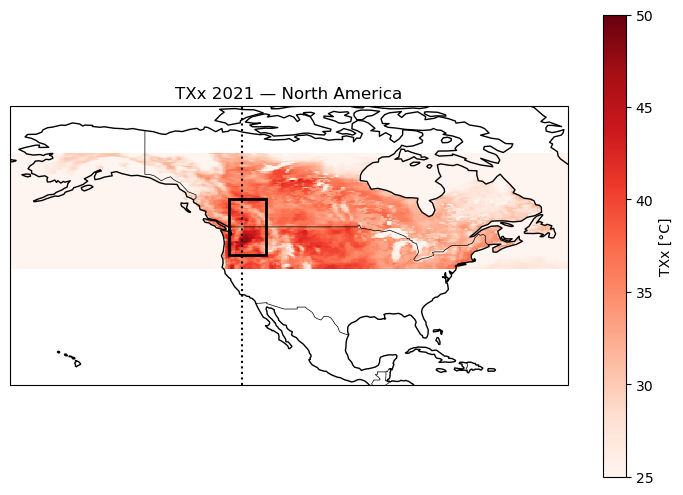

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

da = ds.sel(year=2021).txx - 273.15  # °C

# North America domain (0–360)
lon_min, lon_max = 190, 310
lat_min, lat_max = 15, 75

# subset
lon_slice = slice(lon_min, lon_max) if da.lon[0] < da.lon[-1] else slice(lon_max, lon_min)
lat_slice = slice(lat_min, lat_max) if da.lat[0] < da.lat[-1] else slice(lat_max, lat_min)
da = da.sel(lon=lon_slice, lat=lat_slice)

# ---- BOX you want to draw (edit these) ----
box_lon0, box_lon1 = 360 - 123, 360 - 115  # example: 235–245
box_lat0, box_lat1 = 43, 55

proj = ccrs.PlateCarree(central_longitude=180)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(
    da.lon, da.lat, da,
    cmap="Reds", vmin=25, vmax=50,
    transform=data_crs,
)
plt.colorbar(mesh, ax=ax, label="TXx [°C]")

lon_ref = 360 - 120  # 120°W
lat_ref = 50         # 50°N

ax.plot(
    [lon_ref, lon_ref],
    [lat_min, lat_max],
    linestyle=":",
    color="black",
    linewidth=1.5,
    transform=data_crs,
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# draw rectangle box
rect = mpatches.Rectangle(
    (box_lon0, box_lat0),
    box_lon1 - box_lon0,
    box_lat1 - box_lat0,
    fill=False,
    edgecolor="black",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rect)

# extent
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=data_crs)
ax.set_title("TXx 2021 — North America")
plt.show()


/work/uc1275/u301827/phd/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1797: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = matplotlib.axes.Axes.pcolormesh(self, *args, **kwargs)


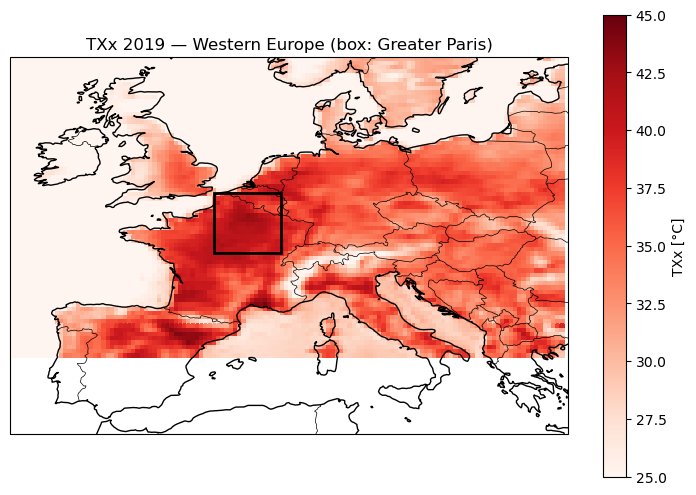

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

# --- TXx for 2019 (K -> °C) ---
da = ds.sel(year=2019).txx - 273.15

# --- West Europe domain in -180..180 convention ---
lon_min, lon_max = -12, 25
lat_min, lat_max = 35, 60

# If dataset uses 0..360, convert to -180..180 and sort
lon0 = float(da.lon.min())
lon1 = float(da.lon.max())
is_0360 = (lon0 >= 0) and (lon1 > 180)

if is_0360:
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180)).sortby("lon")

# Subset (now always continuous)
lon_slice = slice(lon_min, lon_max) if da.lon[0] < da.lon[-1] else slice(lon_max, lon_min)
lat_slice = slice(lat_min, lat_max) if da.lat[0] < da.lat[-1] else slice(lat_max, lat_min)
da = da.sel(lon=lon_slice, lat=lat_slice)

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0, box_lon1 = 1.5, 6
box_lat0, box_lat1 = 47.0, 51.0

# --- Projections ---
proj = ccrs.PlateCarree(central_longitude=0)  # IMPORTANT: centered at Greenwich
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(
    da.lon, da.lat, da,
    cmap="Reds", vmin=25, vmax=45,
    transform=data_crs,
)
plt.colorbar(mesh, ax=ax, label="TXx [°C]")

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Draw rectangle
rect = mpatches.Rectangle(
    (box_lon0, box_lat0),
    box_lon1 - box_lon0,
    box_lat1 - box_lat0,
    fill=False,
    edgecolor="black",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rect)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=data_crs)
ax.set_title("TXx 2019 — Western Europe (box: Greater Paris)")
plt.show()


/work/uc1275/u301827/phd/lib/python3.7/site-packages/cartopy/mpl/geoaxes.py:1797: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  result = matplotlib.axes.Axes.pcolormesh(self, *args, **kwargs)


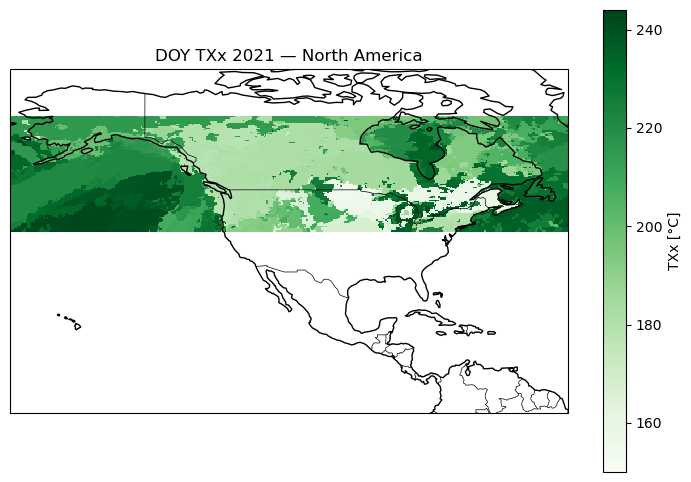

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da = ds.sel(year=2021).txx_doy  # convert to °C

# North America domain
lon_min, lon_max = 190, 310   # 0–360 system
lat_min, lat_max = 1, 75

# subset first (faster + prevents global wrap)
lon_slice = slice(lon_min, lon_max) if da.lon[0] < da.lon[-1] else slice(lon_max, lon_min)
lat_slice = slice(lat_min, lat_max) if da.lat[0] < da.lat[-1] else slice(lat_max, lat_min)

da = da.sel(lon=lon_slice, lat=lat_slice)

# map setup
proj = ccrs.PlateCarree(central_longitude=180)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=proj)

mesh = ax.pcolormesh(
    da.lon,
    da.lat,
    da,
    cmap="Greens", vmin = 150, vmax = 244,
    transform=data_crs,
)

plt.colorbar(mesh, ax=ax, label="TXx [°C]")

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# enforce North America view
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=data_crs)

ax.set_title("DOY TXx 2021 — North America")

plt.show()


txx_max_per_cell: <xarray.DataArray 'txx' (lat: 89, lon: 1280)>
array([[16.094025, 16.140625, 16.187195, ..., 15.66922 , 15.874298,
        15.984161],
       [16.182495, 16.218536, 16.26416 , ..., 15.795197, 15.980347,
        16.08142 ],
       [16.16687 , 16.257385, 16.34793 , ..., 15.826935, 15.970764,
        16.064026],
       ...,
       [37.907776, 38.696075, 34.072296, ..., 36.520294, 35.858795,
        35.646423],
       [38.686005, 38.83841 , 34.565216, ..., 36.678864, 34.274506,
        35.02899 ],
       [37.31241 , 34.186554, 32.681458, ..., 37.94049 , 37.89334 ,
        39.09366 ]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 0.2812 0.5625 0.8438 ... 358.9 359.2 359.4 359.7
  * lat      (lat) float64 64.78 64.5 64.22 63.93 ... 40.89 40.61 40.33 40.05
    plev     float64 ...
year_of_max: <xarray.DataArray 'year' (lat: 89, lon: 1280)>
array([[2018., 2018., 2018., ..., 2018., 2018., 2018.],
       [2018., 2018., 2018., ..., 2018., 2018., 2018.],
       [2018

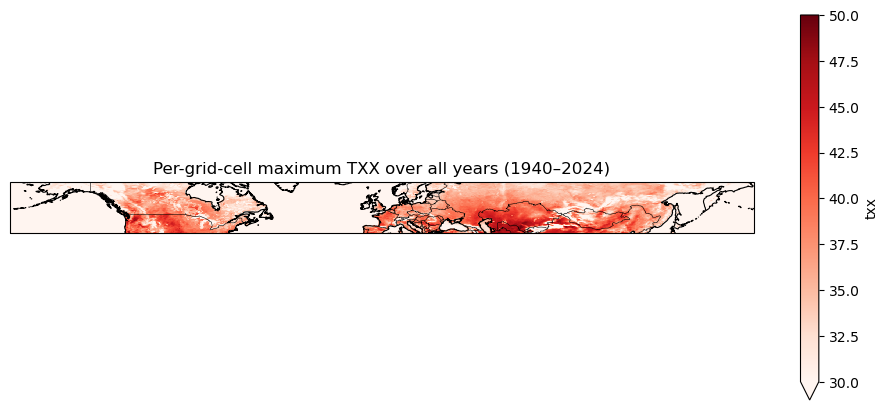


Example cell:
lat, lon = 52.41215530640741 180.0
max TXX = 13.014251708984375
year of max = 2013


In [5]:
# --- Copy/paste ready: map of per-grid-cell max TXX over all years ---
# Each grid cell picks its own hottest year (i.e., max over 'year').

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------
# Load dataset
# -----------------------
path = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path)

# -----------------------
# Per-grid-cell maximum TXX across all years
# Result dims: (lat, lon)
# -----------------------
txx_max_per_cell = ds["txx"].max("year")-273.15

# Optional: also keep the year when the max happens (useful for checks)
year_of_max = ds["txx"].idxmax("year")   # coords are the actual year labels (1940..2024)

print("txx_max_per_cell:", txx_max_per_cell)
print("year_of_max:", year_of_max)

# -----------------------
# Plot map
# -----------------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

txx_max_per_cell.plot(
    ax=ax,
    transform=proj,
    x="lon",
    y="lat",
    vmin = 30, vmax = 50, 
    cmap = "Reds",
    add_colorbar=True,
)

ax.set_title("Per-grid-cell maximum TXX over all years (1940–2024)")
plt.show()

# -----------------------
# (Optional) sanity: print a random grid cell's max + year
# -----------------------
ilat = int(len(ds.lat) // 2)
ilon = int(len(ds.lon) // 2)
print("\nExample cell:")
print("lat, lon =", float(ds.lat[ilat]), float(ds.lon[ilon]))
print("max TXX =", float(txx_max_per_cell.isel(lat=ilat, lon=ilon)))
print("year of max =", int(year_of_max.isel(lat=ilat, lon=ilon)))


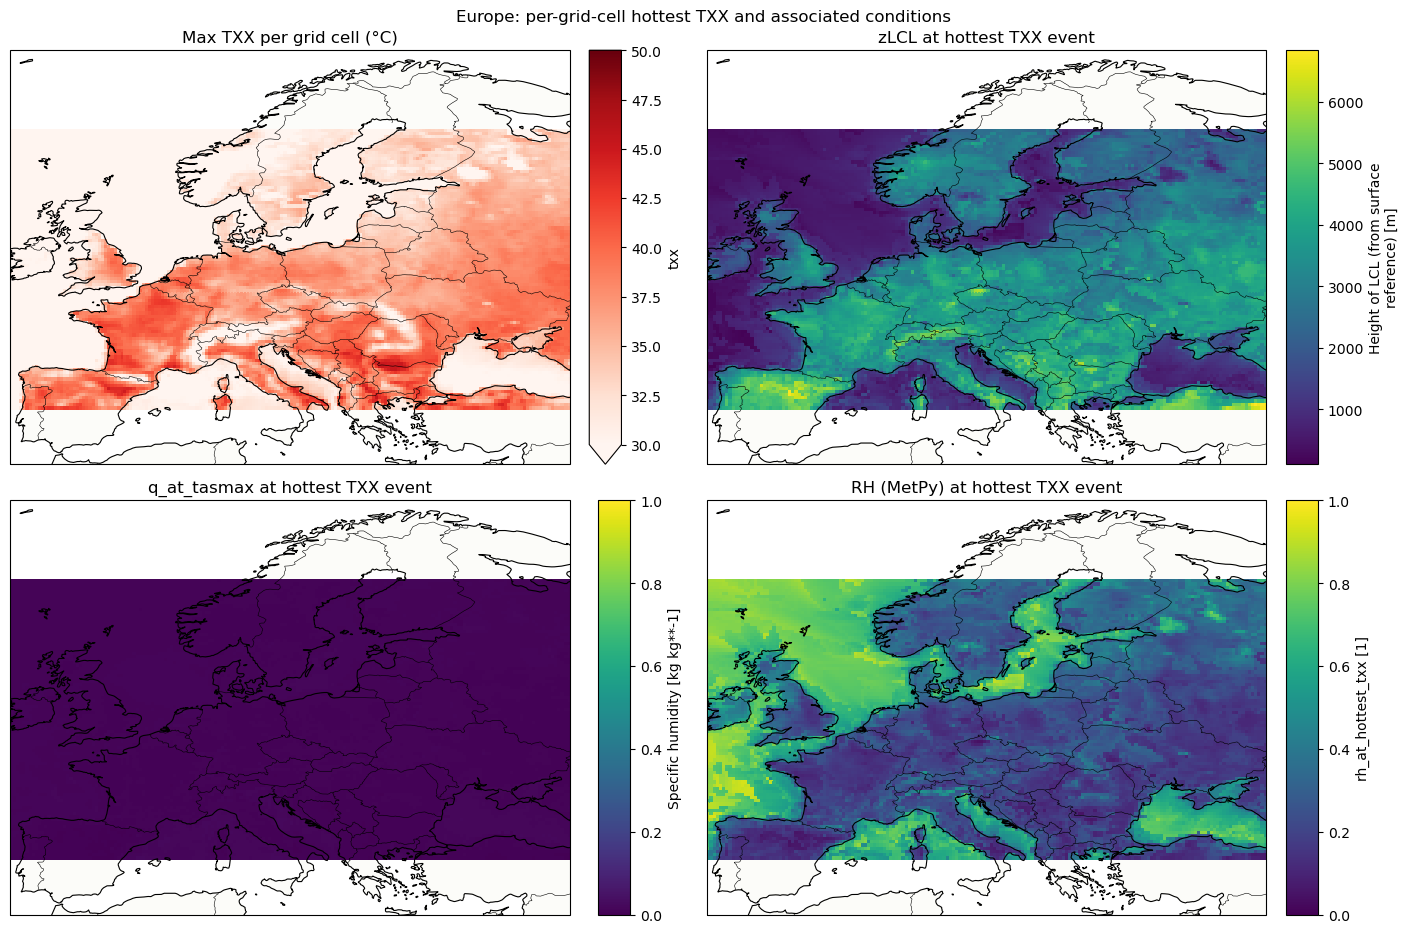


Sanity check cell:
lat, lon: 52.41215530640741 25.03125
max TXX (°C): 34.518707275390625
year of max: 2015
zLCL at max: 3374.740966796875
q at max: 0.006338648963719606
RH at max: 0.2044704407453537


In [6]:
# --- Robust Europe crop + per-grid-cell hottest TXX + zLCL/q/RH at that event ---
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units

# -----------------------
# Load dataset
# -----------------------
path = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
ds = xr.open_dataset(path)

# -----------------------
# Define Europe bounds
# lon in degrees East, dataset uses 0..360
# Europe: lon ~ [-10, 40], lat ~ [35, 72]
# Convert -10 -> 350 in 0..360 convention
# -----------------------
lat_min, lat_max = 35.0, 72.0
lon_west_360, lon_east_360 = 350.0, 40.0

# ---- Robust cropping that works with descending lat and 0..360 wrap ----
lat = ds["lat"]
lon = ds["lon"]

lat_mask = (lat >= lat_min) & (lat <= lat_max)
lon_mask = (lon >= lon_west_360) | (lon <= lon_east_360)

ds_eur = ds.where(lat_mask & lon_mask, drop=True)

# Safety checks (prevents the xarray plot "index -1" error)
if ds_eur.dims.get("lat", 0) == 0 or ds_eur.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Europe crop returned empty lat/lon! "
        f"lat size={ds_eur.dims.get('lat', 0)}, lon size={ds_eur.dims.get('lon', 0)}. "
        f"Check bounds or coordinate conventions."
    )

# Sort longitudes so the map doesn't jump at 0/360
ds_eur = ds_eur.sortby("lon")

# -----------------------
# 1) Per-grid-cell hottest TXX across all years
# -----------------------
txx = ds_eur["txx"]  # (year, lat, lon)

txx_max = txx.max("year") - 273.15  # °C
i_hot = txx.argmax("year")          # (lat, lon) integer indices along 'year'

# (Optional) year label of max per cell (nice to keep around)
year_of_max = txx.idxmax("year")    # (lat, lon) year labels (1940..2024)

# -----------------------
# 2) Variables at hottest-TXX year (per grid cell)
# -----------------------
zLCL_hot = ds_eur["zLCL"].isel(year=i_hot)
q_hot    = ds_eur["q_at_tasmax"].isel(year=i_hot)

T_hot  = ds_eur["txx"].isel(year=i_hot)     # K (assumed)
Td_hot = ds_eur["2d_at_tasmax"].isel(year=i_hot)    # K (assumed)

# -----------------------
# 3) RH via MetPy at hottest-TXX event (per grid cell)
# -----------------------
Tq  = T_hot.values  * units.kelvin
Tdq = Td_hot.values * units.kelvin

rh = mpcalc.relative_humidity_from_dewpoint(Tq, Tdq)  # fraction 0..1

rh_hot = xr.DataArray(
    rh.magnitude,
    coords=T_hot.coords,
    dims=T_hot.dims,
    name="rh_at_hottest_txx",
    attrs={"units": "1"}
)

# -----------------------
# 4) Plot: 4-panel Europe maps
# -----------------------
proj = ccrs.PlateCarree()

fields = [
    (txx_max,  "Max TXX per grid cell (°C)", dict(vmin=30, vmax=50, cmap="Reds")),
    (zLCL_hot, "zLCL at hottest TXX event",  dict()),
    (q_hot,    "q_at_tasmax at hottest TXX event", dict(vmin=0, vmax=1)),
    (rh_hot,   "RH (MetPy) at hottest TXX event", dict(vmin=0, vmax=1)),
]

fig, axes = plt.subplots(
    2, 2, figsize=(14, 9),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

for ax, (da, title, kwargs) in zip(axes.flat, fields):
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, alpha=0.15)

    da.plot(
        ax=ax,
        transform=proj,
        x="lon",
        y="lat",
        add_colorbar=True,
        **kwargs
    )

    # Europe extent in -180..180 for Cartopy PlateCarree
    ax.set_extent([-10, 40, 35, 72], crs=proj)
    ax.set_title(title)

fig.suptitle("Europe: per-grid-cell hottest TXX and associated conditions", y=1.02)
plt.show()

# -----------------------
# 5) Tiny sanity check at one grid cell (middle of the domain)
# -----------------------
ilat = int(ds_eur.dims["lat"] // 2)
ilon = int(ds_eur.dims["lon"] // 2)

print("\nSanity check cell:")
print("lat, lon:", float(ds_eur.lat[ilat].item()), float(ds_eur.lon[ilon].item()))
print("max TXX (°C):", float(txx_max.isel(lat=ilat, lon=ilon).item()))
print("year of max:", int(year_of_max.isel(lat=ilat, lon=ilon).item()))
print("zLCL at max:", float(zLCL_hot.isel(lat=ilat, lon=ilon).item()))
print("q at max:", float(q_hot.isel(lat=ilat, lon=ilon).item()))
print("RH at max:", float(rh_hot.isel(lat=ilat, lon=ilon).item()))


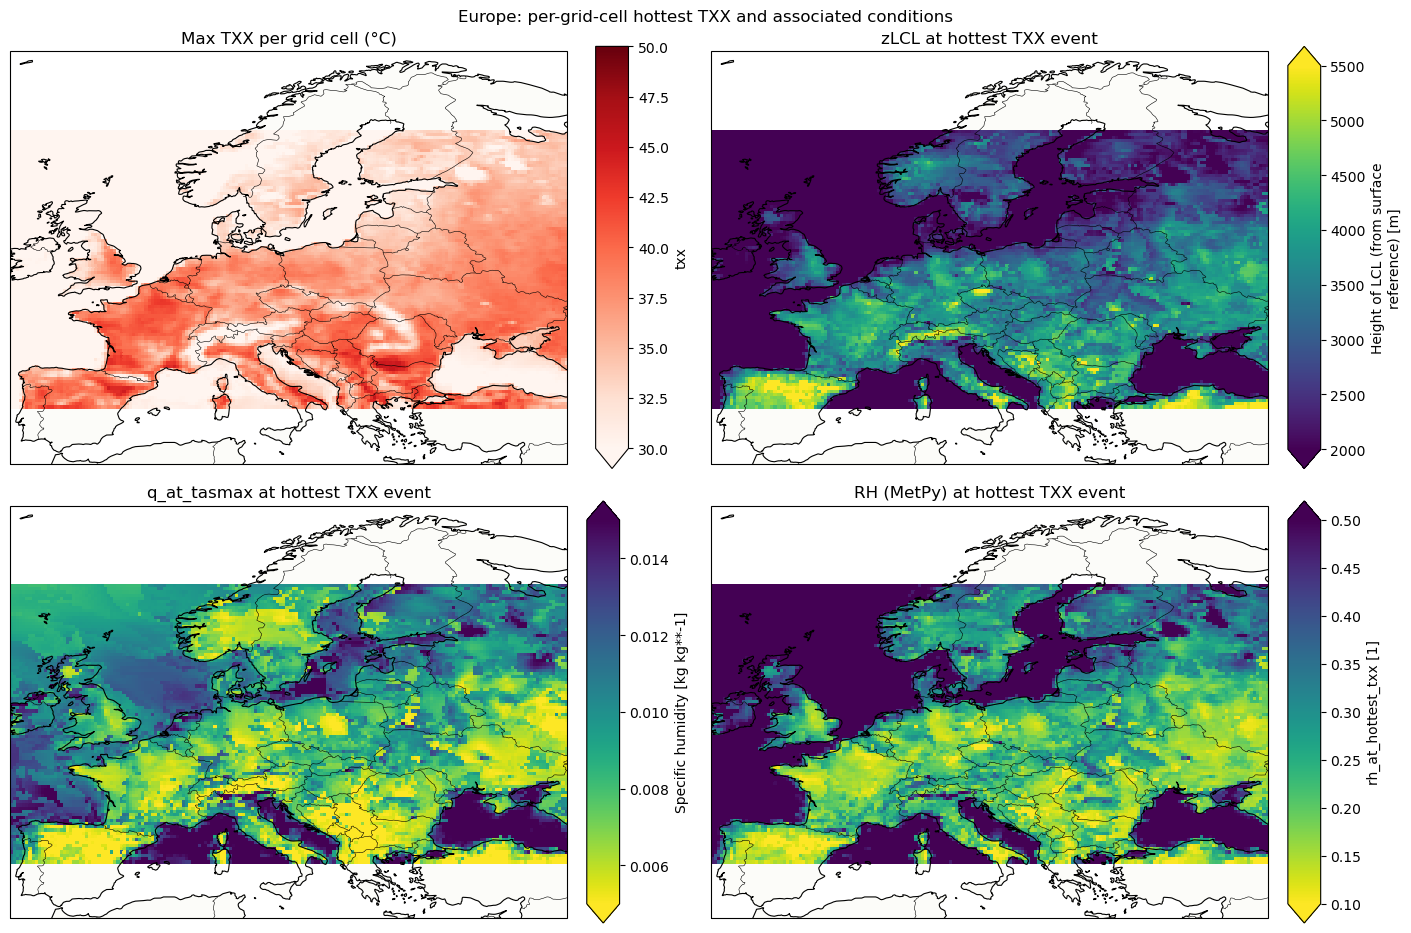


Sanity check cell:
lat, lon: 52.41215530640741 25.03125
max TXX (°C): 34.518707275390625
year of max: 2015
zLCL at max: 3374.740966796875
q at max: 0.006338648963719606
RH at max: 0.2044704407453537


In [7]:
proj = ccrs.PlateCarree()

fields = [
    (txx_max,  "Max TXX per grid cell (°C)", dict(vmin=30, vmax=50, cmap="Reds")),
    (zLCL_hot, "zLCL at hottest TXX event",  dict(vmin=2000, vmax=5500)),
    (q_hot,    "q_at_tasmax at hottest TXX event", dict(vmin=0.005, vmax=0.015, cmap="viridis_r")),
    (rh_hot,   "RH (MetPy) at hottest TXX event", dict(vmin=0.1, vmax=0.5, cmap="viridis_r")),
]

fig, axes = plt.subplots(
    2, 2, figsize=(14, 9),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

for ax, (da, title, kwargs) in zip(axes.flat, fields):
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, alpha=0.15)

    da.plot(
        ax=ax,
        transform=proj,
        x="lon",
        y="lat",
        add_colorbar=True,
        **kwargs
    )

    # Europe extent in -180..180 for Cartopy PlateCarree
    ax.set_extent([-10, 40, 35, 72], crs=proj)
    ax.set_title(title)

fig.suptitle("Europe: per-grid-cell hottest TXX and associated conditions", y=1.02)
plt.show()

# -----------------------
# 5) Tiny sanity check at one grid cell (middle of the domain)
# -----------------------
ilat = int(ds_eur.dims["lat"] // 2)
ilon = int(ds_eur.dims["lon"] // 2)

print("\nSanity check cell:")
print("lat, lon:", float(ds_eur.lat[ilat].item()), float(ds_eur.lon[ilon].item()))
print("max TXX (°C):", float(txx_max.isel(lat=ilat, lon=ilon).item()))
print("year of max:", int(year_of_max.isel(lat=ilat, lon=ilon).item()))
print("zLCL at max:", float(zLCL_hot.isel(lat=ilat, lon=ilon).item()))
print("q at max:", float(q_hot.isel(lat=ilat, lon=ilon).item()))
print("RH at max:", float(rh_hot.isel(lat=ilat, lon=ilon).item()))


In [8]:
# --- Use precomputed q-quantiles (per grid cell) to classify q_at_tasmax at hottest TXX ---
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_q_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_q_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_q_quant)  # quantile thresholds per grid cell

# -----------------------
# Define Europe bounds (0..360 lon convention)
# Europe: lon ~ [-10, 40], lat ~ [35, 72]
# -----------------------
lat_min, lat_max = 35.0, 72.0
lon_west_360, lon_east_360 = 350.0, 40.0

def crop_europe_0_360(ds_in, lat_name="lat", lon_name="lon"):
    lat = ds_in[lat_name]
    lon = ds_in[lon_name]
    lat_mask = (lat >= lat_min) & (lat <= lat_max)
    lon_mask = (lon >= lon_west_360) | (lon <= lon_east_360)
    out = ds_in.where(lat_mask & lon_mask, drop=True).sortby(lon_name)
    if out.dims.get(lat_name, 0) == 0 or out.dims.get(lon_name, 0) == 0:
        raise ValueError(
            f"Europe crop empty! lat size={out.dims.get(lat_name, 0)}, lon size={out.dims.get(lon_name, 0)}"
        )
    return out

ds_eur  = crop_europe_0_360(ds,  lat_name="lat", lon_name="lon")
dsq_eur = crop_europe_0_360(dsq, lat_name="lat", lon_name="lon")

# -----------------------
# 1) Per-grid-cell hottest TXX across all years (from your file)
# -----------------------
txx = ds_eur["txx"]              # (year, lat, lon)
i_hot = txx.argmax("year")       # (lat, lon) integer index of hottest year

# Only q_at_tasmax at that hottest-TXX year (per grid cell)
q_hot = ds_eur["q_at_tasmax"].isel(year=i_hot)

NameError: name 'cat' is not defined

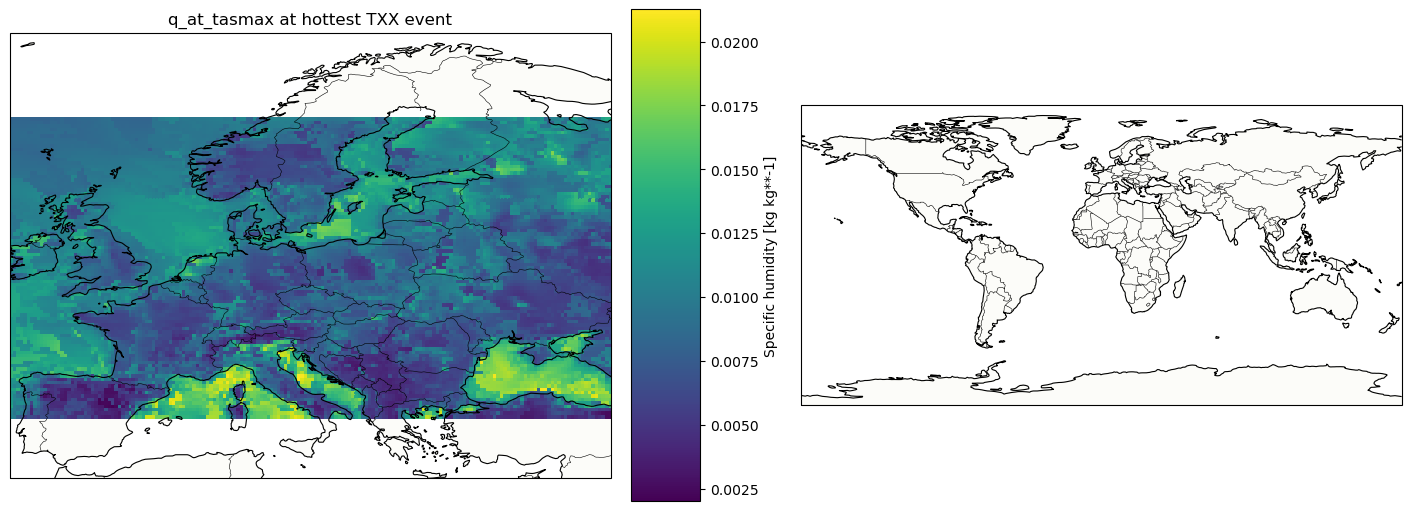

In [9]:
# -----------------------
# 4) Plot: category map + (optional) the raw q_hot map
# -----------------------
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

# Left: raw q at hottest TXX
ax = axes[0]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)
q_hot.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    add_colorbar=True
)
ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("q_at_tasmax at hottest TXX event")

# Right: category map (discrete)
ax = axes[1]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

# Use a discrete colormap; if you prefer, replace "tab10" with another
im = cat.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap="Reds_r", vmin=-0.5, vmax=6.5, levels = 8,
    add_colorbar=True
)

# Make the colorbar show category labels
cbar = im.colorbar
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("q quantile category at hottest TXX")

plt.show()


In [ ]:
# -----------------------
# 2) Load per-grid-cell quantile thresholds for q (from quantiles file)
# -----------------------
# user-provided complementary quantiles (will contain the same set as before, but reversed)
qs = 1 - np.array([0.10, 0.35, 0.50, 0.65, 0.85, 0.90, 0.95, 0.975, 0.99])

# dryness = low-q tail, so we sort ascending and then use the same thresholds as before
ps = np.sort(qs)  # -> [0.01, 0.025, 0.05, 0.10, 0.15, 0.35, 0.50, 0.65, 0.90]

# load quantiles field
if "q_quantiles" in dsq_eur.data_vars:
    qQ = dsq_eur["q_quantiles"]
else:
    first_name = list(dsq_eur.data_vars)[0]
    print(f"WARNING: 'q_quantiles' not found; using '{first_name}' instead.")
    qQ = dsq_eur[first_name]

# robust selection in case quantile coords are float-ish (e.g. 0.1000000001)
def qsel(p):
    return qQ.sel(quantile=p, method="nearest", tolerance=1e-8)

# pick thresholds (same names as before)
q01  = qsel(ps[0])
q025 = qsel(ps[1])
q05  = qsel(ps[2])
q10  = qsel(ps[3])
q15  = qsel(ps[4])
q35  = qsel(ps[5])
q50  = qsel(ps[6])
q65  = qsel(ps[7])
q90  = qsel(ps[8])

# classify: codes 0..6 (dry-focused) -- unchanged
# 0: <1%       extremely dry
# 1: 1–2.5%
# 2: 2.5–5%
# 3: 5–10%     very dry
# 4: 10–15%    dry
# 5: 15–35%    slightly dry
# 6: >=35%     not-dry (near-normal to wet)
cat = xr.full_like(q_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(q_hot < q01, 0, cat)
cat = xr.where((q_hot >= q01)  & (q_hot < q025), 1, cat)
cat = xr.where((q_hot >= q025) & (q_hot < q05),  2, cat)
cat = xr.where((q_hot >= q05)  & (q_hot < q10),  3, cat)
cat = xr.where((q_hot >= q10)  & (q_hot < q15),  4, cat)
cat = xr.where((q_hot >= q15)  & (q_hot < q35),  5, cat)
cat = xr.where(q_hot >= q35, 6, cat)

cat = cat.rename("q_dry_category_at_hottest_txx")
cat.attrs["codes"] = "0:<p01, 1:p01-02.5, 2:p02.5-05, 3:p05-10, 4:p10-15, 5:p15-35, 6:>=p35"

labels = [
    "<1%  extremely dry",
    "1–2.5%",
    "2.5–5%",
    "5–10%  very dry",
    "10–15%  dry",
    "15–35%  slightly dry",
    "≥35%  not-dry",
]

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 3, figsize=(20, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

tasmax_hot = txx.isel(year=i_hot)-273.15
# ------------------------------------------------------------------
# Left: TXX (tasmax at hottest event)
ax = axes[0]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

tasmax_hot.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap="Reds", vmin = 30, vmax = 45, levels = 16,
    add_colorbar=True
)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("TXX (tasmax) at hottest event")

# ------------------------------------------------------------------
# Middle: raw q at hottest TXX
ax = axes[1]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

q_hot.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    add_colorbar=True
)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("q at hottest TXX event")

# ------------------------------------------------------------------
# Right: category map (discrete)
ax = axes[2]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

im = cat.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap="RdBu",
    vmin=-0.5, vmax=6.5,
    levels=8,
    add_colorbar=True
)

cbar = im.colorbar
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("q quantile category at hottest TXX")

plt.show()


In [ ]:
# -----------------------
# 2) Load per-grid-cell quantile thresholds for q (from quantiles file)
# -----------------------
qs = 1 - np.array([0.10, 0.35, 0.50, 0.65, 0.85, 0.90, 0.95, 0.975, 0.99])
ps = np.sort(qs)  # -> [0.01, 0.025, 0.05, 0.10, 0.15, 0.35, 0.50, 0.65, 0.90]

# load quantiles field
if "q_quantiles" in dsq_eur.data_vars:
    qQ = dsq_eur["q_quantiles"]
else:
    first_name = list(dsq_eur.data_vars)[0]
    print(f"WARNING: 'q_quantiles' not found; using '{first_name}' instead.")
    qQ = dsq_eur[first_name]

# IMPORTANT: quantile coord in your file is descending -> sort it so .sel() works reliably
qQ = qQ.sortby("quantile")

# pick thresholds (same names as before)
q01  = qQ.sel(quantile=ps[0])
q025 = qQ.sel(quantile=ps[1])
q05  = qQ.sel(quantile=ps[2])
q10  = qQ.sel(quantile=ps[3])
q15  = qQ.sel(quantile=ps[4])
q35  = qQ.sel(quantile=ps[5])
q50  = qQ.sel(quantile=ps[6])
q65  = qQ.sel(quantile=ps[7])
q90  = qQ.sel(quantile=ps[8])


# classify: codes 0..6 (dry-focused)
# 0: <1%       extremely dry
# 1: 1–2.5%
# 2: 2.5–5%
# 3: 5–10%     very dry
# 4: 10–15%    dry
# 5: 15–35%    slightly dry
# 6: >=35%     not-dry (near-normal to wet)
cat = xr.full_like(q_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(q_hot < q01, 0, cat)
cat = xr.where((q_hot >= q01)  & (q_hot < q025), 1, cat)
cat = xr.where((q_hot >= q025) & (q_hot < q05),  2, cat)
cat = xr.where((q_hot >= q05)  & (q_hot < q10),  3, cat)
cat = xr.where((q_hot >= q10)  & (q_hot < q15),  4, cat)
cat = xr.where((q_hot >= q15)  & (q_hot < q35),  5, cat)
cat = xr.where(q_hot >= q35, 6, cat)

cat = cat.rename("q_dry_category_at_hottest_txx")
cat.attrs["codes"] = "0:<p01, 1:p01-02.5, 2:p02.5-05, 3:p05-10, 4:p10-15, 5:p15-35, 6:>=p35"

labels = [
    "<1%  extremely dry",
    "1–2.5%",
    "2.5–5%",
    "5–10%  very dry",
    "10–15%  dry",
    "15–35%  slightly dry",
    "≥35%  not-dry",
]



# -----------------------
# 4) Plot: category map + (optional) the raw q_hot map
# -----------------------
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

# Left: raw q at hottest TXX
ax = axes[0]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)
q_hot.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    add_colorbar=True
)
ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("q_at_tasmax at hottest TXX event")

# Right: category map (discrete)
ax = axes[1]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

# Use a discrete colormap; if you prefer, replace "tab10" with another
im = cat.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap="Reds_r", vmin=-0.5, vmax=6.5, levels = 8,
    add_colorbar=True
)

# Make the colorbar show category labels
cbar = im.colorbar
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("q quantile category at hottest TXX")

plt.show()

#


In [ ]:
# --- Use precomputed t500-quantiles (per grid cell) to classify t500_at_tasmax at hottest TXX ---
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_t500_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_t500_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_t500_quant)  # quantile thresholds per grid cell

# -----------------------
# Define Europe bounds (0..360 lon convention)
# -----------------------
lat_min, lat_max = 35.0, 72.0
lon_west_360, lon_east_360 = 350.0, 40.0

def crop_europe_0_360(ds_in, lat_name="lat", lon_name="lon"):
    lat = ds_in[lat_name]
    lon = ds_in[lon_name]
    lat_mask = (lat >= lat_min) & (lat <= lat_max)
    lon_mask = (lon >= lon_west_360) | (lon <= lon_east_360)
    out = ds_in.where(lat_mask & lon_mask, drop=True).sortby(lon_name)
    if out.dims.get(lat_name, 0) == 0 or out.dims.get(lon_name, 0) == 0:
        raise ValueError(
            f"Europe crop empty! lat size={out.dims.get(lat_name, 0)}, lon size={out.dims.get(lon_name, 0)}"
        )
    return out

ds_eur  = crop_europe_0_360(ds,  lat_name="lat", lon_name="lon")
dsq_eur = crop_europe_0_360(dsq, lat_name="lat", lon_name="lon")

# -----------------------
# 1) Per-grid-cell hottest TXX across all years (from your file)
# -----------------------
txx = ds_eur["txx"]              # (year, lat, lon)
i_hot = txx.argmax("year")       # (lat, lon) integer index of hottest year

# t500_at_tasmax at that hottest-TXX year (per grid cell)
# (adjust varname here if yours differs)
t500_hot = ds_eur["t_at_tasmax"].isel(year=i_hot)

# -----------------------
# 2) Load per-grid-cell quantile thresholds for t500 (from quantiles file)
# -----------------------
# HOT end = upper tail
ps = np.array([0.65, 0.85, 0.90, 0.95, 0.975, 0.99])

# load quantiles field (your quantile script saves f"{v}_quantiles"; v="t" -> "t_quantiles")
if "t_quantiles" in dsq_eur.data_vars:
    tQ = dsq_eur["t_quantiles"]
else:
    first_name = list(dsq_eur.data_vars)[0]
    print(f"WARNING: 't_quantiles' not found; using '{first_name}' instead.")
    tQ = dsq_eur[first_name]

# sort quantile coord so .sel() works reliably (your files often store it descending)
tQ = tQ.sortby("quantile")

# if there is a singleton lev dimension, squeeze it out to match (lat,lon)
# (harmless if lev not present)
tQ = tQ.squeeze(drop=True)

# pick thresholds
t65  = tQ.sel(quantile=ps[0])
t85  = tQ.sel(quantile=ps[1])
t90  = tQ.sel(quantile=ps[2])
t95  = tQ.sel(quantile=ps[3])
t975 = tQ.sel(quantile=ps[4])
t99  = tQ.sel(quantile=ps[5])

# -----------------------
# 3) classify: codes 0..6 (hot-focused)
# -----------------------
# 0: <p65      not-hot
# 1: p65–p85
# 2: p85–p90
# 3: p90–p95   very warm
# 4: p95–p97.5 hot
# 5: p97.5–p99 extremely hot
# 6: >=p99     rare extreme hot
cat = xr.full_like(t500_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(t500_hot < t65, 0, cat)
cat = xr.where((t500_hot >= t65)  & (t500_hot < t85),  1, cat)
cat = xr.where((t500_hot >= t85)  & (t500_hot < t90),  2, cat)
cat = xr.where((t500_hot >= t90)  & (t500_hot < t95),  3, cat)
cat = xr.where((t500_hot >= t95)  & (t500_hot < t975), 4, cat)
cat = xr.where((t500_hot >= t975) & (t500_hot < t99),  5, cat)
cat = xr.where(t500_hot >= t99, 6, cat)

cat = cat.rename("t500_hot_category_at_hottest_txx")
cat.attrs["codes"] = "0:<p65, 1:p65-85, 2:p85-90, 3:p90-95, 4:p95-97.5, 5:p97.5-99, 6:>=p99"

labels = [
    "<p65  normal",
    "p65–p85 elevated",
    "p85–p90 warm",
    "p90–p95  very warm",
    "p95–p97.5  hot",
    "p97.5–p99  extremely hot",
    "≥p99  rare extreme",
]

# -----------------------
# 4) Plot: raw t500_hot + category map
# -----------------------
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

# Left: raw t500 at hottest TXX
ax = axes[0]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)
t500_hot.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    add_colorbar=True
)
ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("t500_at_tasmax at hottest TXX event")

# Right: category map (discrete)
ax = axes[1]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

im = cat.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap="Reds", vmin=-0.5, vmax=6.5, levels=8,
    add_colorbar=True
)

cbar = im.colorbar
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("t500 hot-tail category at hottest TXX")

plt.show()


In [ ]:
# -----------------------
# 4) Plot: raw t500_hot + category map (LAND ONLY)
# -----------------------
import regionmask

# build land mask on the ERA5 grid
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    ds_eur["lon"],
    ds_eur["lat"]
) == 0


# apply mask
t500_hot_land = t500_hot.where(land_mask)
cat_land      = cat.where(land_mask)

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

# Left: raw t500 at hottest TXX (land only)
ax = axes[0]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

t500_hot_land.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    add_colorbar=True
)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("t500_at_tasmax at hottest TXX event (land only)")

# Right: category map (discrete, land only)
ax = axes[1]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

from matplotlib.colors import ListedColormap

# category 0 = white, higher categories = progressively darker reds
cmap = ListedColormap([
    "#ffffff",  # 0: <p65  normal (white)
    "#fee5d9",
    "#fcae91",
    "#fb6a4a",
    "#ef3b2c",
    "#cb181d",
    "#67000d",  # 6: extreme
])

im = cat_land.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap=cmap, vmin=-0.5, vmax=6.5, levels=8,
    add_colorbar=True
)

cbar = im.colorbar
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("t500 hot-tail category at hottest TXX (land only)")

plt.show()



In [10]:
# -----------------------
# 1) Per-grid-cell hottest TXX across all years (from your file)
# -----------------------
txx = ds_eur["txx"]              # (year, lat, lon)
i_hot = txx.argmax("year")       # (lat, lon) integer index of hottest year

# t500_at_tasmax at that hottest-TXX year (per grid cell)
# (adjust varname here if yours differs)
t500_hot = ds_eur["t500_premax_3d"].isel(year=i_hot)

# -----------------------
# 2) Load per-grid-cell quantile thresholds for t500 (from quantiles file)
# -----------------------
# HOT end = upper tail
ps = np.array([0.65, 0.85, 0.90, 0.95, 0.975, 0.99])

# load quantiles field (your quantile script saves f"{v}_quantiles"; v="t" -> "t_quantiles")
if "t_quantiles" in dsq_eur.data_vars:
    tQ = dsq_eur["t_quantiles"]
else:
    first_name = list(dsq_eur.data_vars)[0]
    print(f"WARNING: 't_quantiles' not found; using '{first_name}' instead.")
    tQ = dsq_eur[first_name]

# sort quantile coord so .sel() works reliably (your files often store it descending)
tQ = tQ.sortby("quantile")

# if there is a singleton lev dimension, squeeze it out to match (lat,lon)
# (harmless if lev not present)
tQ = tQ.squeeze(drop=True)

# pick thresholds
t65  = tQ.sel(quantile=ps[0])
t85  = tQ.sel(quantile=ps[1])
t90  = tQ.sel(quantile=ps[2])
t95  = tQ.sel(quantile=ps[3])
t975 = tQ.sel(quantile=ps[4])
t99  = tQ.sel(quantile=ps[5])

# -----------------------
# 3) classify: codes 0..6 (hot-focused)
# -----------------------
# 0: <p65      not-hot
# 1: p65–p85
# 2: p85–p90
# 3: p90–p95   very warm
# 4: p95–p97.5 hot
# 5: p97.5–p99 extremely hot
# 6: >=p99     rare extreme hot
cat = xr.full_like(t500_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(t500_hot < t65, 0, cat)
cat = xr.where((t500_hot >= t65)  & (t500_hot < t85),  1, cat)
cat = xr.where((t500_hot >= t85)  & (t500_hot < t90),  2, cat)
cat = xr.where((t500_hot >= t90)  & (t500_hot < t95),  3, cat)
cat = xr.where((t500_hot >= t95)  & (t500_hot < t975), 4, cat)
cat = xr.where((t500_hot >= t975) & (t500_hot < t99),  5, cat)
cat = xr.where(t500_hot >= t99, 6, cat)

cat = cat.rename("t500_hot_category_at_hottest_txx")
cat.attrs["codes"] = "0:<p65, 1:p65-85, 2:p85-90, 3:p90-95, 4:p95-97.5, 5:p97.5-99, 6:>=p99"

labels = [
    "<p65  normal",
    "p65–p85 elevated",
    "p85–p90 warm",
    "p90–p95  very warm",
    "p95–p97.5  hot",
    "p97.5–p99  extremely hot",
    "≥p99  rare extreme",
]

# -----------------------
# 4) Plot: raw t500_hot + category map (LAND ONLY)
# -----------------------
import regionmask

# build land mask on the ERA5 grid
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    ds_eur["lon"],
    ds_eur["lat"]
) == 0


# apply mask
t500_hot_land = t500_hot.where(land_mask)
cat_land      = cat.where(land_mask)

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

# Left: raw t500 at hottest TXX (land only)
ax = axes[0]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

t500_hot_land.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    add_colorbar=True
)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("t500_at_tasmax at hottest TXX event (land only)")

# Right: category map (discrete, land only)
ax = axes[1]
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, alpha=0.15)

from matplotlib.colors import ListedColormap

# category 0 = white, higher categories = progressively darker reds
cmap = ListedColormap([
    "#ffffff",  # 0: <p65  normal (white)
    "#fee5d9",
    "#fcae91",
    "#fb6a4a",
    "#ef3b2c",
    "#cb181d",
    "#67000d",  # 6: extreme
])

im = cat_land.plot(
    ax=ax, transform=proj, x="lon", y="lat",
    cmap=cmap, vmin=-0.5, vmax=6.5, levels=8,
    add_colorbar=True
)

cbar = im.colorbar
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

ax.set_extent([-10, 40, 35, 72], crs=proj)
ax.set_title("t500 cat from Max between 3 days prior to day of hottest TXX")

plt.show()


KeyError: 0.85